# Milestone 2 Pushshift Reddit EDA

This notebook performs exploratory data analysis on a Pushshift Reddit dataset stored as
Parquet files on Expanse. The dataset covers Reddit submissions from 2012–2018 across
all subreddits. We examine schema, distributions, data quality, and temporal trends.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from datetime import datetime

# 16 CPUS / 128 GB Memory
spark = SparkSession.builder \
    .appName("PushshiftRedditEDA") \
    .config("spark.driver.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.executor.instances", 6) \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.parquet.enableVectorizedReader", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Matplotlib created a temporary cache directory at /scratch/jkeeton/job_48517196/matplotlib-vkba4ftu because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Spark version: 3.5.0
Spark UI: http://exp-8-15.expanse.sdsc.edu:4040


## 1. Data Loading

We read all Parquet files from `DATA_DIR` and union them into a single Spark DataFrame.

In [2]:
import os
import glob
from pyspark.sql import functions as F

DATA_DIR = "/expanse/lustre/scratch/jkeeton/temp_project/pushshift-reddit/data/"
files = sorted(glob.glob(DATA_DIR + "*.parquet"))

COLS = ["author", "created_utc", "id", "num_comments", "score", 
        "selftext", "subreddit", "subreddit_id", "title"]

def read_one(path):
    return spark.read.parquet(path) \
        .select(*[F.col(c) for c in COLS if c != "created_utc"],
                F.col("created_utc").cast("long").alias("created_utc"))

# Read and union all files
dfs = [read_one(f) for f in files]
df = dfs[0]
for d in dfs[1:]:
    df = df.unionByName(d)

print(f"Files loaded: {len(files)}")
print(f"Partitions: {df.rdd.getNumPartitions()}")


Files loaded: 218
Partitions: 3339


## 2. Schema & Column Descriptions

We retain 9 columns from the raw Pushshift data:

In [3]:
df.printSchema()

root
 |-- author: string (nullable = true)
 |-- id: string (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- score: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- subreddit: string (nullable = true)
 |-- subreddit_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- created_utc: long (nullable = true)



## 3. Dataset Size

We cache the total row count here as `row_count` 

In [4]:
row_count = df.count()
print(f"Total observations: {row_count:,}")

Total observations: 549,662,955


## 4. Numeric Summary Statistics

Summary statistics for `score` and `num_comments`. Both columns follow a heavily
right-skewed distribution typical of social media engagement: the vast majority of posts
receive little attention while a small number go viral. The `min` value for `num_comments`
may be negative this is a known data artifact in Pushshift where comment counts were
recorded before Reddit's counters fully settled, or reflect moderation-related adjustments.
Negative values should be treated as 0 in any downstream modeling.

In [5]:
df.select("score", "num_comments").summary(
    "count", "mean", "stddev", "min", "max"
).show()

+-------+-----------------+-----------------+
|summary|            score|     num_comments|
+-------+-----------------+-----------------+
|  count|        549662934|        549662955|
|   mean| 44.8390808193008|8.358100421739355|
| stddev|707.3788392973761|93.11190659178932|
|    min|                0|             -117|
|    max|           270469|           517003|
+-------+-----------------+-----------------+



### Temporal Coverage

Verifies the date range of the dataset. The `min_utc` and `max_utc` valueshowrm the
years cove.rds.

In [6]:
df.select(
    F.count("created_utc").alias("non_null"),
    F.to_timestamp(F.min("created_utc")).alias("min_utc"),
    F.to_timestamp(F.max("created_utc")).alias("max_utc"),
).show()

+---------+-------------------+-------------------+
| non_null|            min_utc|            max_utc|
+---------+-------------------+-------------------+
|549662955|2012-01-01 00:00:01|2018-12-31 23:59:59|
+---------+-------------------+-------------------+



## 5. Categorical Analysis


We use `approx_count_distinct`, ~2% relative error) rather than exact
distinct counts to avoid expensive full shuffles on hundreds of millions of rows.
If `id_approx_distinct ≈ row_count`, duplicate posts are negligible.

In [5]:

cardinality = df.agg(
    F.approx_count_distinct("author",       rsd=0.02).alias("author_approx_distinct"),
    F.approx_count_distinct("subreddit",    rsd=0.02).alias("subreddit_approx_distinct"),
    F.approx_count_distinct("subreddit_id", rsd=0.02).alias("subreddit_id_approx_distinct"),
    F.approx_count_distinct("id",           rsd=0.02).alias("id_approx_distinct"),
).toPandas()

print(cardinality.T.to_string())
print("\nNote: approx_count_distinct uses HyperLogLog with ~2% relative error.")
print(f"Total rows: {row_count:,} if id_approx_distinct ≈ total rows, duplicates are minimal.")

                                      0
author_approx_distinct         35424036
subreddit_approx_distinct       2330913
subreddit_id_approx_distinct    2233793
id_approx_distinct            560753094

Note: approx_count_distinct uses HyperLogLog with ~2% relative error.
Total rows: 549,662,955 — if id_approx_distinct ≈ total rows, duplicates are minimal.


### Top 20 Subreddits by Post Count

The most-posted subreddits reveal which communities dominate the corpus.
General-interest subreddits (e.g. r/AskReddit, r/pics) are expected to lead.
A high concentration in the top 20 would indicate class imbalance relevant to
subreddit-level modeling tasks.

In [6]:
df.groupBy("subreddit") \
   .agg(F.approx_count_distinct("id").alias("approx_post_count")) \
   .orderBy(F.desc("approx_post_count")) \
   .show(20, truncate=False)

+--------------------+-----------------+
|subreddit           |approx_post_count|
+--------------------+-----------------+
|AskReddit           |13452317         |
|funny               |7803090          |
|AutoNewspaper       |4820574          |
|pics                |4700365          |
|GlobalOffensiveTrade|4555729          |
|videos              |4550961          |
|RocketLeagueExchange|4128743          |
|gaming              |4069437          |
|The_Donald          |3981426          |
|AdviceAnimals       |3852601          |
|leagueoflegends     |3681045          |
|Fireteams           |3573078          |
|news                |3432637          |
|aww                 |3364180          |
|Showerthoughts      |2812992          |
|dirtykikpals        |2505270          |
|worldnews           |2353509          |
|Music               |2268186          |
|politics            |2249858          |
|trees               |2088362          |
+--------------------+-----------------+
only showing top

### Most Prolific Authors

Identifies users responsible for the largest share of submissions. Automated or
bot accounts often appear here. High post counts from a single author may warrant
deduplication or author-level stratification in train/test splits.

In [7]:
# Most prolific authors
df.groupBy("author") \
   .agg(F.approx_count_distinct("id").alias("approx_post_count")) \
   .orderBy(F.desc("approx_post_count")) \
   .show(20, truncate=False)

+-------------------+-----------------+
|author             |approx_post_count|
+-------------------+-----------------+
|[deleted]          |86086708         |
|                   |31174746         |
|AutoNewsAdmin      |5605080          |
|AutoNewspaperAdmin |4820574          |
|-en-               |1828625          |
|ImagesOfNetwork    |1743466          |
|AutoModerator      |1355753          |
|KellyfromLeedsUK   |1339100          |
|politicbot         |1236381          |
|RPBot              |1149346          |
|thefeedbot         |817422           |
|louistoldmeto      |759426           |
|rotoreuters        |711008           |
|Mukhasim           |586725           |
|BitcoinAllBot      |573535           |
|removalbot         |568855           |
|peterboykin        |499509           |
|EcoInternetNewsfeed|475430           |
|phuongnewrich2016  |461214           |
|apksorg            |446785           |
+-------------------+-----------------+
only showing top 20 rows



## 6. Text Length Distributions

Character-level length of `selftext` and `title`. Link posts and image posts have
no body text, so a large share of `selftext` will be null or placeholder strings.
Title length is bounded by Reddit's 300-character limit; very short titles (< 10 chars)
may indicate low-quality or spam submissions.

In [10]:
# length of selftext
df.select(
    F.length("selftext").alias("selftext_len")
).summary("count", "mean", "stddev", "min", "max").show()

# title length
df.select(
    F.length("title").alias("title_len")
).summary("count", "mean", "stddev", "min", "max").show()

+-------+------------------+
|summary|      selftext_len|
+-------+------------------+
|  count|         549662955|
|   mean|158.03158631456253|
| stddev| 641.5849466286304|
|    min|                 0|
|    max|            402033|
+-------+------------------+

+-------+-----------------+
|summary|        title_len|
+-------+-----------------+
|  count|        549662955|
|   mean|50.07374950163778|
| stddev| 37.4499326726957|
|    min|                0|
|    max|             1592|
+-------+-----------------+



## 7. Missing Value Analysis

NULL counts per column as a percentage of total rows. For this dataset we expect:
- `selftext` to have a high null/placeholder rate (link-only posts have no body)
- `score` and `num_comments` to be nearly complete
- `author` nulls to be rare but non-zero (deleted accounts)

Note that Reddit encodes absence with sentinel strings like `[removed]` and `[deleted]`.

In [11]:
# Missing values per column (NULL counts)
total = row_count
missing_exprs = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in COLS
]
missing_df = df.select(missing_exprs)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ["null_count"]
missing_pd["pct_missing"] = (missing_pd["null_count"] / total * 100).round(4)
print(missing_pd.to_string())

              null_count  pct_missing
author                 0       0.0000
created_utc            0       0.0000
id                     0       0.0000
num_comments           0       0.0000
score                 21       0.0000
selftext               0       0.0000
subreddit         306479       0.0558
subreddit_id      306479       0.0558
title                  0       0.0000


### Sentinel Strings in `selftext`

Reddit uses `[removed]` (moderator action) and `[deleted]` (user deletion) as
placeholder strings instead of NULLs.

In [12]:
# selftext often contains placeholder strings instead of NULL
# Check for '[removed]', '[deleted]', and empty strings
df.groupBy(
    F.when(F.col("selftext").isNull(), "<NULL>")
     .when(F.col("selftext") == "", "<empty>")
     .when(F.col("selftext") == "[removed]", "[removed]")
     .when(F.col("selftext") == "[deleted]", "[deleted]")
     .otherwise("<has_text>")
     .alias("selftext_type")
).agg(F.count("*").alias("count")) \
 .orderBy(F.desc("count")) \
 .show()

+-------------+---------+
|selftext_type|    count|
+-------------+---------+
|      <empty>|399545236|
|   <has_text>|150117719|
+-------------+---------+



### Author Type Breakdown

Categorises authors into real users, deleted accounts, AutoModerator, and nulls.
`[deleted]` authors are common in historical Reddit data; these posts lose their
attribution but the content may still be present. AutoModerator posts are bot-generated
and are typically excluded from engagement analysis.

In [3]:
# Check for deleted/anonymous authors
df.groupBy(
    F.when(F.col("author").isNull(), "<NULL>")
     .when(F.col("author") == "[deleted]", "[deleted]")
     .when(F.col("author") == "AutoModerator", "AutoModerator")
     .when(F.col("author") == "", "<empty>")
     .otherwise("<real_user>")
     .alias("author_type")
).agg(F.count("*").alias("count")) \
 .orderBy(F.desc("count")) \
 .show()

+-------------+---------+
|  author_type|    count|
+-------------+---------+
|  <real_user>|444817691|
|    [deleted]| 73272560|
|      <empty>| 30256874|
|AutoModerator|  1315830|
+-------------+---------+



### Duplicate Post Check

Counts rows whose `id` appears more than once. Duplicates can arise from overlapping
Pushshift crawl windows.

In [3]:
# Duplicate check: count posts with duplicate IDs
dup_count = row_count - df.select("id"W).distinct().count()
print(f"Rows with duplicate IDs: {dup_count:,}")

Rows with duplicate IDs: 1


## 8. Visualisations

We set the FIGURES_DIR dynamically, assuming the github repo is cloned in the working directory.

In [11]:
FIGURES_DIR = os.getcwd().split('reddit-engagement-classifier')[0] +\
            'reddit-engagement-classifier/outputs/figures/'

### Plot 1 Monthly Post Volume (2012–2018)

Bar chart of the number of Reddit submissions per calendar month. This reveals the overall growth trajectory of the platform over the study period and highlights any seasonal patterns or anomalies (e.g. a sudden drop may indicate a gap in Pushshift coverage rather than a real decline in activity).

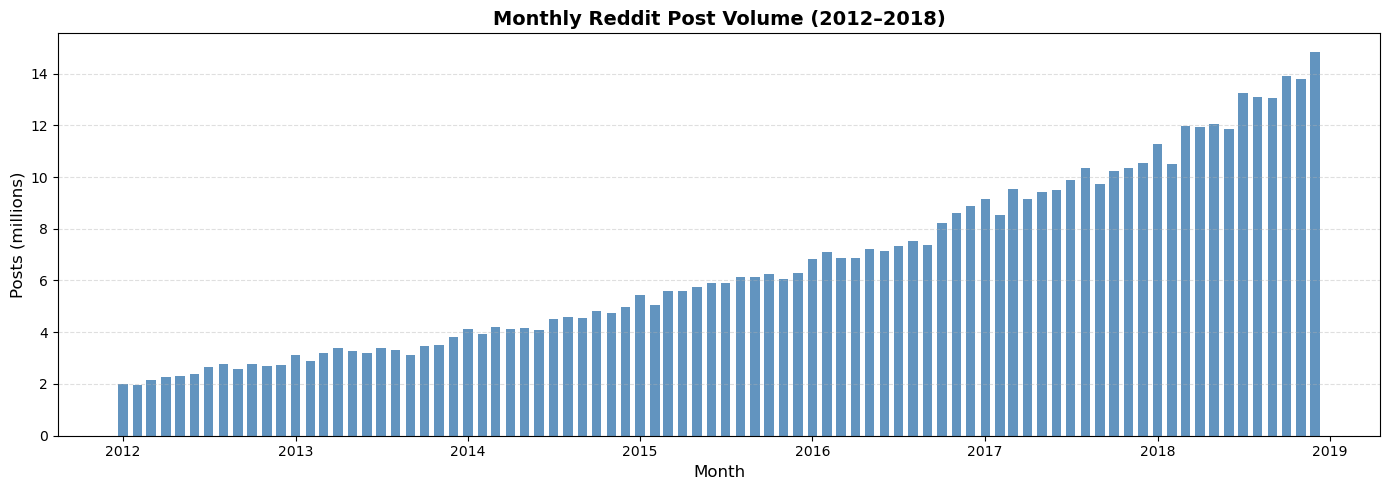

In [12]:
monthly_posts = df.withColumn("year",  F.year(F.to_timestamp("created_utc"))) \
                  .withColumn("month", F.month(F.to_timestamp("created_utc"))) \
                  .groupBy("year", "month") \
                  .agg(F.count("*").alias("post_count")) \
                  .orderBy("year", "month") \
                  .toPandas()

monthly_posts["date"] = pd.to_datetime(
    monthly_posts["year"].astype(str) + "-" + monthly_posts["month"].astype(str).str.zfill(2)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_posts["date"], monthly_posts["post_count"] / 1e6,
       width=20, color="steelblue", edgecolor="none", alpha=0.85)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Posts (millions)", fontsize=12)
ax.set_title("Monthly Reddit Post Volume (2012–2018)", fontsize=14, fontweight="bold")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"plot1_posts_over_time.png"), dpi=150)
plt.show()

### Plot 2  Top 20 Subreddits by Post Count

Horizontal bar chart of the 20 highest-volume subredditasks. Illustrates the long-tail distribution of community activity: a small number of subreddits account for a disproportionate share of all posts, which has implications for class balance in subreddit-classification tasks.

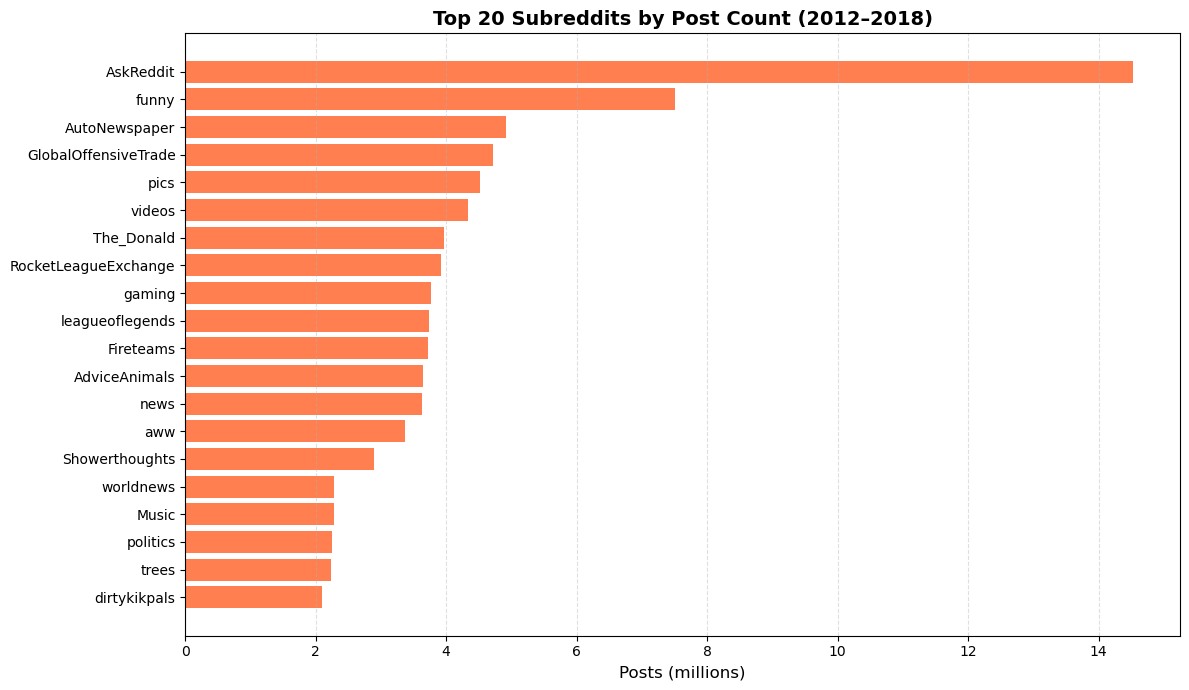

In [13]:
top_subs = df.groupBy("subreddit") \
             .agg(F.count("*").alias("post_count")) \
             .orderBy(F.desc("post_count")) \
             .limit(20) \
             .toPandas()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_subs["subreddit"][::-1], top_subs["post_count"][::-1] / 1e6,
               color="coral", edgecolor="none")
ax.set_xlabel("Posts (millions)", fontsize=12)
ax.set_title("Top 20 Subreddits by Post Count (2012–2018)", fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"plot2_top_subreddits.png"), dpi=150)
plt.show()

### Plot 3 Post Score Distribution (Log-Bucketed)

Posts are bucketed by order of magnitude of their score (0, 1–9, 10–99, etc.). The expected pattern is a right skewed distribution showing that only a fraction of posts reach virality.

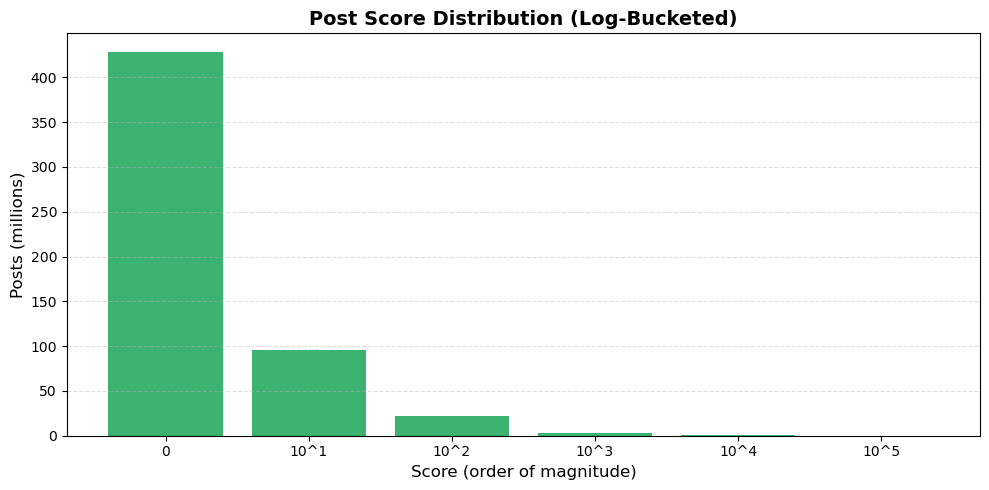

In [14]:
score_bins = df.filter(F.col("score").isNotNull() & (F.col("score") >= 0)) \
               .withColumn("score_log",
                           F.floor(F.log10(F.col("score") + 1)).cast("int")) \
               .groupBy("score_log") \
               .agg(F.count("*").alias("count")) \
               .orderBy("score_log") \
               .toPandas()

# Map log bins to readable labels
labels = [f"10^{int(r)}" if r >= 1 else "0" for r in score_bins["score_log"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(labels, score_bins["count"] / 1e6, color="mediumseagreen", edgecolor="none")
ax.set_xlabel("Score (order of magnitude)", fontsize=12)
ax.set_ylabel("Posts (millions)", fontsize=12)
ax.set_title("Post Score Distribution (Log-Bucketed)", fontsize=14, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"plot3_score_distribution.png"), dpi=150)
plt.show()

### Plot 4 Score vs. Comments (log-log scatter, n=50k sample)

Scatter plot of log₁₀(score+1) vs. log₁₀(num_comments+1) on a 50,000-row sample. A positive OLS trend line indicates that higher-scored posts tend to attract more 
comments, though the relationship has substantial variace.e

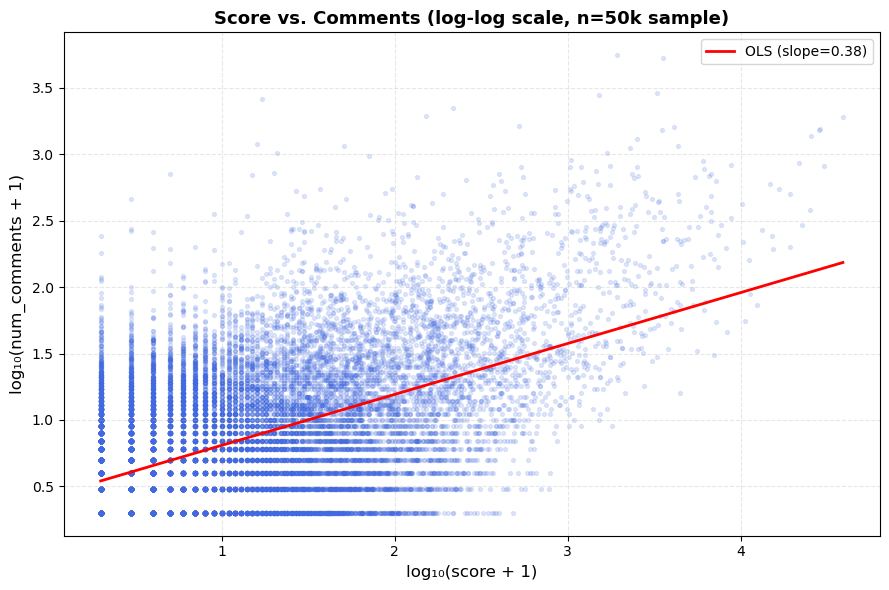

In [15]:
sample_df = df.filter(
    F.col("score").isNotNull() &
    (F.col("score") > 0) &
    (F.col("num_comments") > 0)
).sample(fraction=50000 / row_count, seed=42) \
 .select("score", "num_comments") \
 .limit(50000) \
 .toPandas()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(np.log10(sample_df["score"] + 1),
           np.log10(sample_df["num_comments"] + 1),
           alpha=0.15, s=8, color="royalblue", rasterized=True)

# Compute and draw regression line
x = np.log10(sample_df["score"] + 1)
y = np.log10(sample_df["num_comments"] + 1)
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m * xline + b, color="red", lw=2, label=f"OLS (slope={m:.2f})")

ax.set_xlabel("log₁₀(score + 1)", fontsize=12)
ax.set_ylabel("log₁₀(num_comments + 1)", fontsize=12)
ax.set_title("Score vs. Comments (log-log scale, n=50k sample)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"plot4_score_vs_comments.png"), dpi=150)
plt.show()

### Plot 5 Post Volume by Day of Week

Total submissions aggregated by day of week (UTC).. A midweek peak is typical 
lower weekend volume suggests the platform skews toward office/school hours browsing.

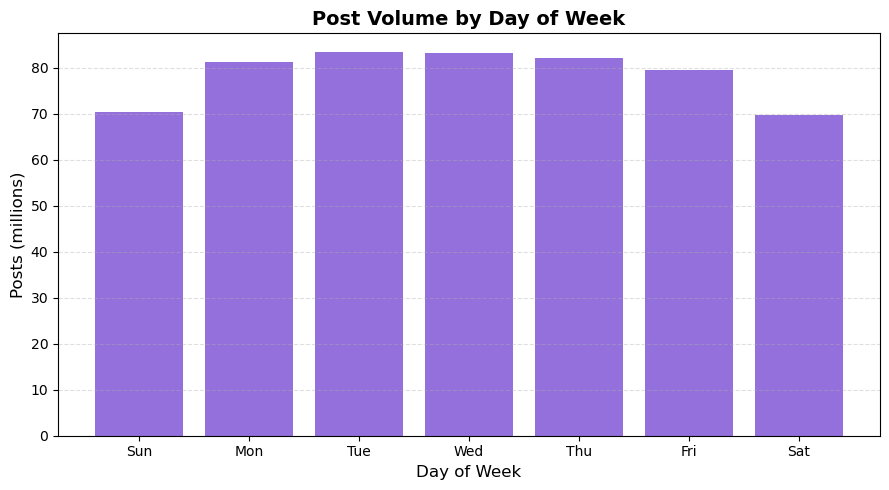

In [16]:
dow_counts = df.withColumn(
    "dow", F.dayofweek(F.to_timestamp("created_utc"))  # 1=Sun, 7=Sat in Spark
).groupBy("dow") \
 .agg(F.count("*").alias("count")) \
 .orderBy("dow") \
 .toPandas()

day_names = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
dow_counts["day_name"] = dow_counts["dow"].apply(lambda x: day_names[x - 1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dow_counts["day_name"], dow_counts["count"] / 1e6,
       color="mediumpurple", edgecolor="none")
ax.set_xlabel("Day of Week", fontsize=12)
ax.set_ylabel("Posts (millions)", fontsize=12)
ax.set_title("Post Volume by Day of Week", fontsize=14, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"plot5_posts_by_dow.png"), dpi=150)
plt.show()

### Plot 6 Mean vs. Median Post Score by Year

Grouped bar chart comparing mean and median score for each year. The persistent
gap between mean and median confirms a right-skewed score distribution in every yean). Any year-over-year trend in t e
median reflects a genuine shift in typical engagement, unaffected by outliers.

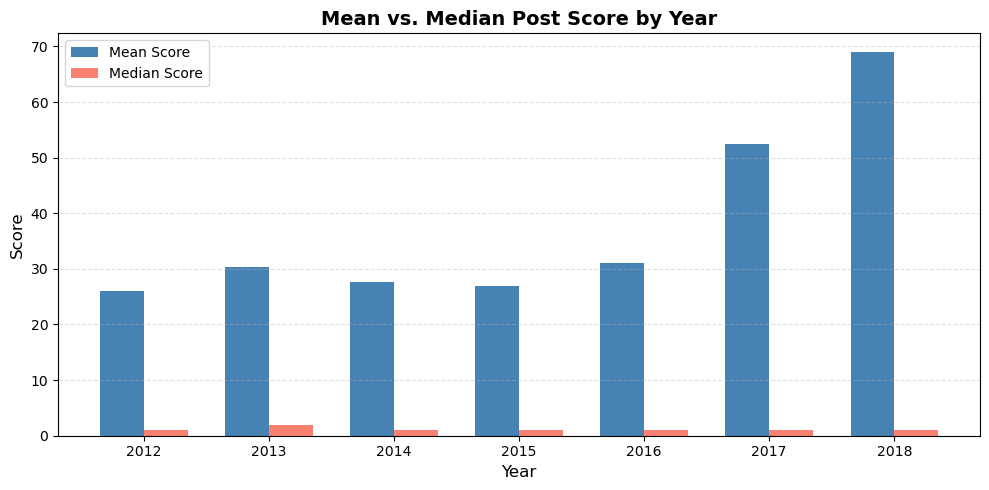

In [17]:
avg_score_year = df.filter(F.col("score").isNotNull()) \
                   .withColumn("year", F.year(F.to_timestamp("created_utc"))) \
                   .groupBy("year") \
                   .agg(
                       F.mean("score").alias("avg_score"),
                       F.expr("percentile_approx(score, 0.5)").alias("median_score")
                   ) \
                   .orderBy("year") \
                   .toPandas()

x = np.arange(len(avg_score_year))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, avg_score_year["avg_score"], width,
       label="Mean Score", color="steelblue", edgecolor="none")
ax.bar(x + width/2, avg_score_year["median_score"], width,
       label="Median Score", color="salmon", edgecolor="none")
ax.set_xticks(x)
ax.set_xticklabels(avg_score_year["year"])
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Mean vs. Median Post Score by Year", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"plot6_avg_score_by_year.png"), dpi=150)
plt.show()